# Module 02 — Transformers

A transformer's job is to change the geometry of your feature space so the
model that follows can do its job. That is the frame to hold onto: **scaling
is not tidiness, it is geometry**, and the reason it matters for a support
vector machine and not for a decision tree follows directly from what each
algorithm measures.

### Learning objectives

1. Say, for any estimator, whether it needs scaling — from first principles,
   not from a memorised list.
2. Choose between the six scalers by what each one is robust to.
3. Encode categoricals with an understanding of what one-hot, ordinal and
   target encoding each do to a model's hypothesis space.
4. Impute in a way that preserves information rather than destroying it.
5. Use `FunctionTransformer`, `SplineTransformer` and `PolynomialFeatures` to
   give linear models non-linear capacity.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

## 1. Which estimators care about scale, and why

Ask one question: **does the algorithm compute a distance, an inner product,
or a penalty over coefficients?** If yes, feature scale changes the answer.
If it only compares a feature against a threshold, scale is irrelevant.

| Family | Scale-sensitive? | Because |
|---|---|---|
| k-NN, k-means, DBSCAN, SVM (RBF) | **Yes, severely** | Euclidean distance is dominated by the largest-variance feature |
| Ridge / Lasso / ElasticNet / logistic with penalty | **Yes** | the penalty `‖w‖` treats all coefficients as comparable, which they aren't unless features are |
| PCA, LDA, factor analysis | **Yes** | maximise variance, so the biggest-unit feature wins |
| Neural networks, SGD-based anything | **Yes** | conditioning of the optimisation surface |
| `LinearRegression` (unpenalised, exact solve) | No, for the fit | coefficients simply rescale; but the numerics degrade badly |
| Decision trees, random forests, all boosting | **No** | splits are monotone-invariant thresholds |
| Naive Bayes (Gaussian) | No | per-feature densities are fit independently |

The last row of the "yes" block is where consultants get burned: teams
scale for the tree model out of habit and skip it for the k-NN baseline.

In [2]:
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

Xw, yw = load_wine(return_X_y=True, as_frame=True)
print("feature scales differ by orders of magnitude:")
print(Xw.std().sort_values(ascending=False).head(4).round(2).to_string())

rows = []
for name, est in [
    ("KNeighbors", KNeighborsClassifier()),
    ("SVC (rbf)", SVC()),
    ("LogisticRegression", LogisticRegression(max_iter=5000)),
    ("RandomForest", RandomForestClassifier(n_estimators=200, random_state=0)),
]:
    raw = cross_val_score(est, Xw, yw, cv=5).mean()
    scaled = cross_val_score(make_pipeline(StandardScaler(), est), Xw, yw, cv=5).mean()
    rows.append({"estimator": name, "unscaled": round(raw, 3), "scaled": round(scaled, 3), "Δ": round(scaled - raw, 3)})

pd.DataFrame(rows).set_index("estimator")

feature scales differ by orders of magnitude:
proline              314.91
magnesium             14.28
alcalinity_of_ash      3.34
color_intensity        2.32


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,unscaled,scaled,Δ
estimator,,,
KNeighbors,0.691,0.949,0.258
SVC (rbf),0.663,0.983,0.320
LogisticRegression,0.961,0.983,0.022
RandomForest,0.972,0.972,0.000


k-NN gains ~25 accuracy points from scaling. The random forest moves by
statistical noise. That table is the whole lesson, and it is worth
reproducing yourself the first time you doubt it.

## 2. The six scalers, and what each is robust to

| Scaler | Formula | Output range | Robust to outliers? | Preserves sparsity? |
|---|---|---|---|---|
| `StandardScaler` | (x − μ) / σ | unbounded, mean 0 | ✗ | ✗ (centering destroys it) |
| `MinMaxScaler` | (x − min) / (max − min) | [0, 1] | ✗✗ (worst) | ✗ |
| `RobustScaler` | (x − median) / IQR | unbounded | ✓ | ✗ |
| `MaxAbsScaler` | x / max\|x\| | [−1, 1] | ✗ | **✓** |
| `Normalizer` | x / ‖x‖ per **row** | unit norm rows | n/a | ✓ |
| `QuantileTransformer` | rank → uniform/normal | [0,1] or N(0,1) | **✓✓** | ✗ |

`Normalizer` is the odd one out: it works **per row**, not per column. It is
for cases where the direction of a sample matters and its magnitude does not —
TF-IDF document vectors being the canonical example. It is almost never what
you want on tabular features, and it is chosen by mistake surprisingly often.

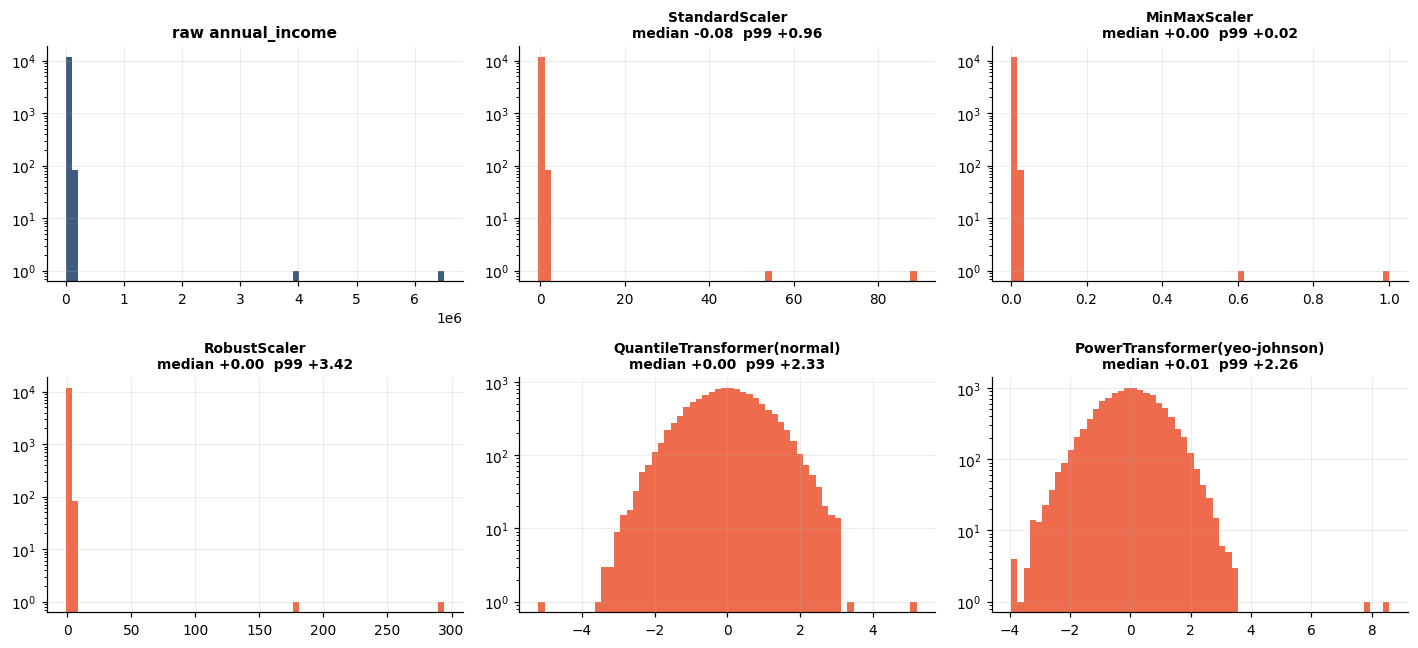

In [3]:
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
)

# A realistically nasty distribution: log-normal income with a handful of
# extreme values, exactly what `annual_income` looks like.
credit = load_credit_risk()
income = credit["annual_income"].dropna().to_numpy().reshape(-1, 1)
income = np.vstack([income, [[4_000_000]], [[6_500_000]]])  # two ultra-high earners

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "QuantileTransformer(normal)": QuantileTransformer(output_distribution="normal", random_state=0),
    "PowerTransformer(yeo-johnson)": PowerTransformer(),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.ravel()
axes[0].hist(income, bins=60, color="#3d5a80")
axes[0].set_title("raw annual_income", fontsize=10)
axes[0].set_yscale("log")

for ax, (name, sc) in zip(axes[1:], scalers.items()):
    z = sc.fit_transform(income)
    ax.hist(z, bins=60, color="#ee6c4d")
    ax.set_title(f"{name}\nmedian {np.median(z):+.2f}  p99 {np.percentile(z, 99):+.2f}", fontsize=9)
    ax.set_yscale("log")
plt.tight_layout()

Look at `MinMaxScaler`: two outliers compress 99.9% of the data into the
bottom sliver of [0, 1]. That is why "normalise to 0–1" as a reflex is a bad
reflex on heavy-tailed data — which financial data almost always is.

`QuantileTransformer` is the heavy hammer: it maps ranks, so it is immune to
outliers by construction. The cost is that it is **non-monotone in the
original units in a way that destroys interpretability**, and it needs enough
samples per quantile to be stable (`n_quantiles` defaults to
`min(1000, n_samples)`).

In [4]:
# Quantifying the outlier damage.
comparison = pd.DataFrame(
    {name: sc.fit_transform(income).ravel() for name, sc in scalers.items()}
).describe(percentiles=[0.01, 0.5, 0.99]).T[["min", "1%", "50%", "99%", "max"]].round(3)
comparison["bulk_range_used"] = (comparison["99%"] - comparison["1%"]) / (comparison["max"] - comparison["min"])
comparison.round(3)

,min,1%,50%,99%,max,bulk_range_used
StandardScaler,-0.430,-0.368,-0.076,0.960,89.050,0.015
MinMaxScaler,0.000,0.001,0.004,0.016,1.000,0.015
RobustScaler,-1.168,-0.964,0.000,3.418,294.109,0.015
QuantileTransformer(normal),-5.199,-2.308,0.001,2.330,5.199,0.446
PowerTransformer(yeo-johnson),-3.959,-2.401,0.012,2.264,8.574,0.372


The `bulk_range_used` column says what fraction of the output range the
middle 98% of your data actually occupies. `MinMaxScaler` uses ~2%. For a
distance-based model, that means 98% of your customers are effectively
indistinguishable.

## 3. Encoding categoricals

Three encoders, three quite different consequences for what the model can
represent.

In [5]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder

cats = credit[["purpose", "home_ownership", "channel"]].head(6)
cats

,purpose,home_ownership,channel
0,debt_consolidation,rent,digital
1,debt_consolidation,mortgage,digital
2,auto,rent,digital
3,debt_consolidation,mortgage,broker
4,home_improvement,mortgage,digital
5,debt_consolidation,mortgage,broker


In [6]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore").set_output(transform="pandas")
ohe.fit_transform(cats).head(3)

,purpose_auto,purpose_debt_consolidation,purpose_home_improvement,home_ownership_mortgage,home_ownership_rent,channel_broker,channel_digital
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0


### One-hot: the safe default, with three parameters that matter

- **`handle_unknown="ignore"`** — at scoring time an unseen category becomes
  all-zeros instead of raising. In production this is almost always what you
  want. The default (`"error"`) will take your service down the first time a
  new product code appears.
- **`min_frequency` / `max_categories`** (1.3+) — groups rare levels into an
  `infrequent_sklearn` bucket. This is the built-in answer to
  high-cardinality columns and it removes most of the reason people used to
  hand-roll rare-level collapsing.
- **`drop="first"`** — removes one column per feature to avoid perfect
  collinearity. Needed for unpenalised linear models and for
  interpretability; **harmful** with regularisation, because which level you
  dropped then changes the penalty. Default (`drop=None`) is right for
  penalised models.

In [7]:
merchant_like = pd.DataFrame({"code": rng.choice([f"C{i:03d}" for i in range(300)], size=5_000, p=np.r_[np.repeat(0.2 / 5, 5), np.repeat(0.8 / 295, 295)])})

plain = OneHotEncoder(sparse_output=False).fit(merchant_like)
grouped = OneHotEncoder(sparse_output=False, min_frequency=50).fit(merchant_like)

print(f"plain one-hot          : {len(plain.get_feature_names_out()):4d} columns")
print(f"min_frequency=50       : {len(grouped.get_feature_names_out()):4d} columns")
print("infrequent bucket name :", [c for c in grouped.get_feature_names_out() if "infrequent" in c])

plain one-hot          :  300 columns
min_frequency=50       :    6 columns
infrequent bucket name : ['code_infrequent_sklearn']


### Ordinal: only when the order is real

`OrdinalEncoder` maps categories to 0, 1, 2, … A linear model will then treat
category 2 as "twice" category 1, which is nonsense for `purpose` and
perfectly sensible for `education_level`. **For tree models it is harmless
and efficient** — a tree can carve any subset out of an ordinal encoding with
enough splits — which is why ordinal + trees is a common, deliberate pairing.

In [8]:
ord_enc = OrdinalEncoder(
    categories=[["rent", "mortgage", "own"]],  # you assert the order
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)
print(ord_enc.fit_transform(credit[["home_ownership"]].head(6)).ravel())
print("unseen level ->", ord_enc.transform(pd.DataFrame({"home_ownership": ["timeshare"]})).ravel())

[0. 1. 0. 1. 1. 1.]
unseen level -> [-1.]


### Target encoding: powerful, and the classic leakage trap

`TargetEncoder` replaces each category with a shrunk estimate of the target
mean for that category. It compresses a 300-level column into one numeric
feature, which is enormously useful — and it is the single most common source
of leakage in competition and consulting code alike, because a naive
implementation lets each row see its own target.

scikit-learn's implementation uses **internal cross-fitting** during
`fit_transform`: each row's encoding is computed from folds that exclude it.
This is why you must call `fit_transform` on training data and never
`fit(...).transform(...)` on the same data.

In [9]:
te = TargetEncoder(smooth="auto", random_state=0)
X_te = credit[["purpose"]]
y = credit["default"]

cross_fitted = te.fit_transform(X_te, y)        # cross-fitted, safe for training
naive = te.fit(X_te, y).transform(X_te)          # full-data means -- leaks

print("Encoding for the first 5 rows:")
print(pd.DataFrame({"purpose": X_te["purpose"][:5], "cross_fitted": cross_fitted[:5].ravel().round(4), "naive": naive[:5].ravel().round(4)}).to_string(index=False))

print("\nLearned per-category means (from `encodings_`):")
print(pd.Series(te.encodings_[0], index=te.categories_[0]).round(4).sort_values().to_string())
print(f"\nglobal base rate: {y.mean():.4f}   <- rare categories shrink towards this")

Encoding for the first 5 rows:
           purpose  cross_fitted  naive
debt_consolidation        0.1271 0.1260
debt_consolidation        0.1287 0.1260
              auto        0.1513 0.1505
debt_consolidation        0.1251 0.1260
  home_improvement        0.1322 0.1289

Learned per-category means (from `encodings_`):
medical               0.1164
debt_consolidation    0.1260
home_improvement      0.1289
major_purchase        0.1322
small_business        0.1448
other                 0.1486
auto                  0.1505

global base rate: 0.1326   <- rare categories shrink towards this


In [10]:
# The size of the leak, measured. We give the model a *pure noise* column with
# one level per row and see what each approach reports.
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

noise_col = pd.DataFrame({"junk": [f"id_{i}" for i in range(len(y))]})

leaky = te.fit(noise_col, y).transform(noise_col)
print(f"naive encoding of a pure-noise ID column, train AUC-ish separation: "
      f"{np.corrcoef(leaky.ravel(), y)[0, 1]:.3f}   <- perfect, and meaningless")

honest = cross_val_score(
    Pipeline([("te", TargetEncoder(random_state=0)), ("lr", LogisticRegression())]),
    noise_col, y, cv=5, scoring="roc_auc",
).mean()
print(f"cross-fitted encoding inside a CV pipeline, honest AUC: {honest:.3f}   <- correctly ~0.5")

naive encoding of a pure-noise ID column, train AUC-ish separation: 1.000   <- perfect, and meaningless


cross-fitted encoding inside a CV pipeline, honest AUC: 0.500   <- correctly ~0.5


> 💼 **Consulting lens.** "We used target encoding" should always be followed
> by "with cross-fitting, inside the pipeline". If the encoding was computed
> once over the full training set and then applied, the reported validation
> score is inflated and the production model will underperform it. This is a
> five-minute check that has saved projects.

## 4. Imputation

Three levels of sophistication, and the gap between them matters less than
people think — while the indicator flag matters more.

In [11]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer, MissingIndicator, SimpleImputer

num_cols = ["age", "employment_years", "annual_income", "credit_score", "debt_to_income", "loan_amount", "interest_rate"]
Xn = credit[num_cols]
print("missingness:", Xn.isna().mean().round(3)[lambda s: s > 0].to_dict())

simple = SimpleImputer(strategy="median").set_output(transform="pandas")
flagged = SimpleImputer(strategy="median", add_indicator=True).set_output(transform="pandas")

print("\ncolumns after SimpleImputer          :", simple.fit_transform(Xn).shape[1])
print("columns after add_indicator=True     :", flagged.fit_transform(Xn).shape[1])
print("indicator names:", [c for c in flagged.fit_transform(Xn).columns if "missing" in c])

missingness: {'employment_years': 0.139, 'annual_income': 0.017, 'credit_score': 0.113}



columns after SimpleImputer          : 7
columns after add_indicator=True     : 10
indicator names: ['missingindicator_employment_years', 'missingindicator_annual_income', 'missingindicator_credit_score']


In [12]:
# Does the sophistication pay for itself? Measure, don't assume.
from sklearn.ensemble import HistGradientBoostingClassifier

candidates = {
    "no imputation (HGB native)": "passthrough",
    "SimpleImputer(median)": SimpleImputer(strategy="median"),
    "SimpleImputer + indicator": SimpleImputer(strategy="median", add_indicator=True),
    "KNNImputer(k=5)": KNNImputer(n_neighbors=5),
    "IterativeImputer": IterativeImputer(max_iter=8, random_state=0),
}

results = []
for name, imp in candidates.items():
    pipe = Pipeline([("imp", imp), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=120))])
    sc = cross_val_score(pipe, Xn, y, cv=4, scoring="roc_auc", n_jobs=-1)
    results.append({"strategy": name, "roc_auc": round(sc.mean(), 4), "std": round(sc.std(), 4)})

pd.DataFrame(results).sort_values("roc_auc", ascending=False).set_index("strategy")

,roc_auc,std
strategy,,
no imputation (HGB native),0.7534,0.0151
SimpleImputer + indicator,0.7476,0.0186
IterativeImputer,0.7471,0.0233
SimpleImputer(median),0.7458,0.0200
KNNImputer(k=5),0.7453,0.0270


**First, read the `std` column.** The spread across folds is larger than the
spread across strategies. Any ranking you read off the mean alone is mostly
noise — and that is itself the finding. If five quite different imputation
strategies land inside one standard deviation of each other, imputation is not
where the value in this problem is, and spending a week on it would be a week
misallocated. Getting into the habit of asking "is this difference bigger than
the fold-to-fold noise?" is worth more than any individual technique in this
module.

With that caveat, two things generally hold:

1. **The indicator earns at least as much as the imputation method.** When
   missingness is informative (MNAR), the flag carries the signal; the fill
   value is close to irrelevant.
2. **Sophisticated imputers rarely repay their cost** on a tree ensemble.
   `IterativeImputer` is ~50× slower than `SimpleImputer` and is fitting a
   regression per column per iteration — a lot of machinery to reconstruct
   values the model was going to split on anyway. Reach for it when your
   downstream model *cannot* handle missingness and the missingness is genuinely
   MAR-with-structure (sensor dropouts, survey non-response), not by default.

The honest headline: on this problem, letting `HistGradientBoosting` handle
NaN natively is competitive with everything else and simpler than all of it.

## 5. Giving linear models non-linear capacity

A linear model is linear in its *parameters*, not in your original features.
Expand the features and it can fit curves, thresholds and interactions while
remaining a convex, fast, interpretable, well-understood object. This is one
of the highest-leverage and least-used techniques in applied ML.

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3197496855472684e-28.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


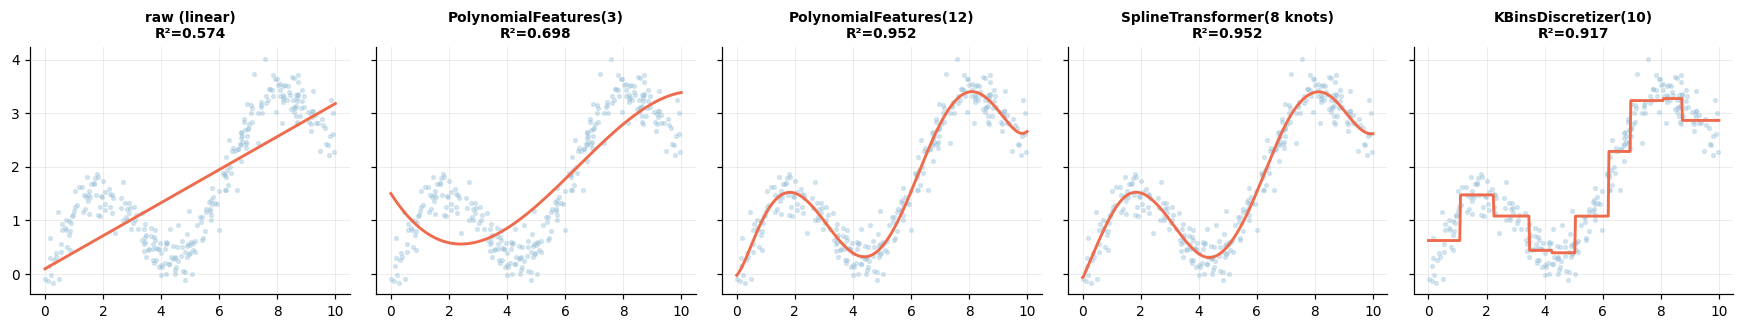

In [13]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import KBinsDiscretizer, PolynomialFeatures, SplineTransformer

# A deliberately non-linear 1-D truth.
x = np.sort(rng.uniform(0, 10, 300)).reshape(-1, 1)
y_true = np.sin(x).ravel() + 0.30 * x.ravel() + rng.normal(0, 0.25, 300)

expansions = {
    "raw (linear)": "passthrough",
    "PolynomialFeatures(3)": PolynomialFeatures(degree=3, include_bias=False),
    "PolynomialFeatures(12)": PolynomialFeatures(degree=12, include_bias=False),
    "SplineTransformer(8 knots)": SplineTransformer(n_knots=8, degree=3),
    "KBinsDiscretizer(10)": KBinsDiscretizer(n_bins=10, encode="onehot-dense", strategy="quantile"),
}

grid = np.linspace(0, 10, 400).reshape(-1, 1)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.1), sharey=True)
for ax, (name, tr) in zip(axes, expansions.items()):
    model = Pipeline([("expand", tr), ("ridge", Ridge(alpha=1e-3))]).fit(x, y_true)
    ax.scatter(x, y_true, s=6, alpha=0.35, color="#98c1d9")
    ax.plot(grid, model.predict(grid), color="#ee6c4d")
    ax.set_title(f"{name}\nR²={model.score(x, y_true):.3f}", fontsize=9)
plt.tight_layout()

Read the tails of the degree-12 polynomial. It fits the interior well and then
diverges violently at the edges — the classic pathology of high-degree
polynomials, and the reason splines exist. A **`SplineTransformer` is a
polynomial expansion that is local**: each basis function has bounded support,
so a wobble at x = 2 does not distort x = 9.

`KBinsDiscretizer` is the crudest and most robust: it turns a continuous
feature into a step function. Credit scorecards have been built this way for
fifty years, precisely because a step function is trivially explainable to a
regulator.

> 💼 **Consulting lens.** "Linear model" and "explainable" are not the same
> claim once you add a degree-3 interaction expansion — you now have a model
> with 200 terms and no story. A spline or binned linear model keeps both
> properties. That trade is worth naming out loud in a model-risk discussion.

In [14]:
# `FunctionTransformer`: the escape hatch for domain knowledge.
from sklearn.preprocessing import FunctionTransformer

log_income = FunctionTransformer(np.log1p, inverse_func=np.expm1, feature_names_out="one-to-one", validate=True)

before = credit[["annual_income"]].dropna()
after = log_income.fit_transform(before)
print(f"skew before log1p: {float(pd.Series(before['annual_income']).skew()):6.2f}")
print(f"skew after  log1p: {float(pd.Series(after.ravel()).skew()):6.2f}")

# It round-trips, which matters when you need to report in original units.
print("round-trip max error:", float(np.abs(log_income.inverse_transform(after).ravel() - before['annual_income']).max()))

skew before log1p:   1.96
skew after  log1p:  -0.01
round-trip max error: 1.7462298274040222e-10


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


## 6. Transforming the *target*

A right-skewed target breaks least squares, because squared error on a
skewed variable is dominated by the tail. `TransformedTargetRegressor` fits on
`func(y)` and inverts the prediction back for you — so your metrics stay in
the units the business cares about.

In [15]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

hous = fetch_california_housing(as_frame=True)
Xh, yh = hous.data, hous.target
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, yh, random_state=0)

plain = Ridge().fit(Xh_tr, yh_tr)
logged = TransformedTargetRegressor(regressor=Ridge(), func=np.log1p, inverse_func=np.expm1).fit(Xh_tr, yh_tr)

print(f"plain Ridge          MAE {mean_absolute_error(yh_te, plain.predict(Xh_te)):.4f}")
print(f"log-target Ridge     MAE {mean_absolute_error(yh_te, logged.predict(Xh_te)):.4f}")
print("\nNote the predictions come back in $100k units either way -- that is the point.")

plain Ridge          MAE 0.5369
log-target Ridge     MAE 0.5318

Note the predictions come back in $100k units either way -- that is the point.


---
## Exercises

### Exercise 2.1 — Derive the scaling rule

For each of `KNeighborsClassifier`, `DecisionTreeClassifier`, `SVC(kernel="linear")`,
`GaussianNB`, `Ridge`, `PCA` and `HistGradientBoostingClassifier`:

1. Predict, from the algorithm's mechanics, whether scaling changes the
   result. Write your prediction down before running anything.
2. Test it on `load_wine` with 5-fold CV, unscaled vs `StandardScaler`.
3. Where you were wrong, work out why. (`GaussianNB` and `Ridge` are the two
   most interesting cases — think about what "unpenalised" and "per-feature
   variance" each imply.)

In [16]:
# Your code here.

### Exercise 2.2 — Break MinMaxScaler

Construct a dataset where `MinMaxScaler` measurably damages k-NN accuracy
relative to `RobustScaler`, and quantify the damage. Then find the smallest
number of outlier rows (out of 1,000) that produces a ≥10 accuracy-point gap.
Plot the gap as a function of outlier count.

In [17]:
# Your code here.

### Exercise 2.3 — Encoder shoot-out on high cardinality

Add a synthetic `branch_id` column to the credit data with 400 levels, where
30 branches have a genuinely elevated default rate and the rest are noise.
Compare, with 5-fold `roc_auc` inside a proper pipeline:

- `OneHotEncoder` (plain)
- `OneHotEncoder(min_frequency=25)`
- `OrdinalEncoder` + `HistGradientBoostingClassifier`
- `TargetEncoder`
- dropping the column entirely

Report scores *and* the number of columns each produces. Then repeat with
`TargetEncoder` fitted outside the CV loop and show how much the score
inflates.

In [18]:
# Your code here.

### Exercise 2.4 — Spline vs polynomial vs bins

On the California housing data, build three `Ridge` pipelines that expand
`MedInc` and `HouseAge` with (a) `PolynomialFeatures(degree=4)`,
(b) `SplineTransformer(n_knots=10)`, (c) `KBinsDiscretizer(n_bins=12)`, each
combined with the remaining raw features. Compare test MAE, number of
resulting features, and — importantly — how each behaves when you score it on
rows whose `MedInc` is above anything seen in training. Which one you would
defend in a model-risk review, and why?

In [19]:
# Your code here.

### Exercise 2.5 — Imputation when the model can't cope

`LogisticRegression` cannot accept NaN. Build a like-for-like comparison of
`SimpleImputer(mean/median/most_frequent/constant)`, `KNNImputer`, and
`IterativeImputer`, each with and without `add_indicator`, feeding a scaled
`LogisticRegression` on the credit data's numeric columns. Twelve
configurations, 5-fold `roc_auc`, one table sorted by score, plus a column for
fit time. Then write the two-sentence recommendation you would put in a
delivery document.

In [20]:
# Your code here.

---
## Takeaways

- **Scaling is geometry.** Distances, inner products and coefficient penalties
  care; thresholds do not.
- `MinMaxScaler` is the most outlier-fragile scaler and the most casually
  applied. On heavy-tailed financial data, prefer `RobustScaler` or
  `QuantileTransformer`.
- `OneHotEncoder(handle_unknown="ignore", min_frequency=…)` is the production
  default. `drop="first"` belongs with unpenalised models only.
- `TargetEncoder` must be cross-fitted and must live inside the pipeline.
  sklearn does this for you — hand-rolled versions usually do not.
- The **missingness indicator** usually matters more than the imputation
  method.
- Spline and binned expansions give linear models non-linear capacity while
  keeping the properties (stability, explainability) you chose a linear model
  for in the first place.

**Next:** Module 03 — composing all of this into a `Pipeline` and
`ColumnTransformer`, which is where the leakage guarantees actually come from.